# Results analysis
Load the raw per-fold test predictions, recompute every table number, build
confusion matrices, and inspect ROC/AUC. Change `cfg` and re-run. Uses the same
helpers that generated the paper tables, so numbers match exactly. See
`RESULTS_LAYOUT.md` for the full data map.

In [1]:
import sys, pathlib, json, itertools
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
ROOT = pathlib.Path.cwd().parent; sys.path.insert(0, str(ROOT))
RESULTS, DATA = ROOT/'results', ROOT/'data'

from nn.metrics import roc_auc_certification, certification_confusion
# The exact-label / join helpers used to build the tables:
from scripts.compute_roc_auc import (_ik_truth, _mimo_truth, _acopf_chordal_truth,
                                      _feasible_theta)
pd.set_option('display.width', 200, 'display.max_columns', 30)

## The finished tables
These are exactly what feeds the paper. Recompute them from scratch below.

In [2]:
summary = pd.read_csv(RESULTS/'roc_auc_summary.csv')
knap = pd.read_csv(RESULTS/'roc_auc_knapsack.csv')
display(summary); display(knap)

,config,experiment,relaxation,case,mean_vr,std_vr,mean_relax_gap,mean_opt_gap,pct_feasible,mae,ae_p5,ae_p95,delta0,auc,n_pos,n_neg
0,qcqp,QCQP,SDP,--,2.652215,4.631978,0.000000e+00,9.757676,100.00,0.002244,2.622621e-06,0.009380,0.002652,0.999974,10036,9964
1,mimo,MIMO,SDP,--,0.794182,0.405622,4.544105e-04,0.001875,100.00,0.016729,1.038450e-03,0.046869,0.000794,1.000000,19984,16
2,ik_lass1,IK,Lasserre-1,--,0.036381,0.093665,2.926311e-03,0.011166,99.86,0.000077,1.334274e-07,0.000408,0.000036,0.975088,19100,872
3,ik_lass2,IK,Lasserre-2,--,0.039307,0.094040,-3.958228e-08,0.011166,99.86,0.000084,6.342278e-07,0.000407,0.000039,0.989888,19100,872
4,acopf_socp_case9,AC-OPF,SOCP,case9,4692.008763,1451.765660,3.987012e-02,0.000040,100.00,0.716651,4.133829e-02,2.128065,4.692009,NaN,20000,0
5,acopf_socp_case14,AC-OPF,SOCP,case14,7048.653945,1905.988795,5.802426e+00,0.005742,100.00,2.815054,7.208011e-02,12.196074,7.048654,NaN,20000,0
6,acopf_socp_case39,AC-OPF,SOCP,case39,33515.296207,12532.064360,6.598311e+00,4.110926,93.02,33.218756,5.700443e-01,142.524527,33.515296,0.955866,18568,36
7,acopf_socp_case89pegase,AC-OPF,SOCP,case89pegase,7274.321503,1409.802056,6.459655e+00,0.025528,95.52,2.519826,2.507649e-02,13.426019,7.274322,NaN,19092,0
8,acopf_socp_case118,AC-OPF,SOCP,case118,113180.221151,28637.445237,2.716958e+02,2.014698,100.00,27.784154,7.397909e-01,143.940736,113.180221,NaN,20000,0
9,acopf_socp_case300,AC-OPF,SOCP,case300,586140.953259,133012.992355,8.034376e+02,235.259372,80.30,267.001803,8.155624e+00,1179.125289,586.140953,0.899299,15508,260


,config,n_train,n_test,mean_cost,mae,mean_greedy_gap,auc,n_pos,n_neg,delta0
0,knapsack_n20000,20000,5000,28.783643,0.190504,0.206922,0.785092,4544,15456,0.028784
1,knapsack_n80000,80000,20000,28.760523,0.142319,0.209855,0.838828,17888,62112,0.028761


## Load raw predictions for any config
`g`=NN pred, `v`=relaxation value `v_r`, `f`=local/heuristic cost. Four folds pooled.

In [3]:
def load_pred(config):
    p = RESULTS/config/'fold_test_predictions.csv'
    if not p.exists(): p = RESULTS/'acopf-cert'/config/'fold_test_predictions.csv'
    return pd.read_csv(p)

def true_value(config):
    '''Exact / best-available v(theta), aligned & pooled to match load_pred(config).'''
    if config == 'qcqp':      return load_pred('qcqp')['v'].values
    if config == 'mimo':      return np.tile(_mimo_truth(), 4)
    if config in ('ik_lass1','ik_lass2'): return np.tile(_ik_truth(int(config[-1])), 4)
    if config.startswith('acopf_chordal'): return load_pred(config)['v'].values
    if config == 'acopf_socp_case2869pegase': return load_pred(config)['v'].values
    if config.startswith('acopf_socp'):
        case = config.replace('acopf_socp_','')
        n = (load_pred(config)['fold']==0).sum()
        return np.tile(_acopf_chordal_truth(case, n), 4)
    raise KeyError(config)

cfg = 'ik_lass1'   # <-- change me
d = load_pred(cfg); d.head()

,fold,idx,g,v,f
0,0,0,1.544394e-04,1.722966e-04,1.722452e-04
1,0,1,3.063828e-02,3.032839e-02,3.032839e-02
2,0,2,8.559865e-02,8.517260e-02,8.517259e-02
3,0,3,2.150030e-01,2.154763e-01,2.154763e-01
4,0,4,-8.903444e-07,4.081657e-08,3.295735e-17


## Recompute the data-generation + certification numbers for one config
Reproduces the corresponding row of `roc_auc_summary.csv`.

In [4]:
g, v, f = d['g'].values, d['v'].values, d['f'].values
vt = true_value(cfg)
delta0 = 1e-3*np.nanmean(v)
err = np.abs(g - v)
print(f'mean v_r        = {np.nanmean(v):.5g}  (std {np.nanstd(v):.4g})')
print(f'mean relax gap  = {np.nanmean(vt - v):.5g}   (v - v_r)')
print(f'mean opt gap    = {np.nanmean(f - vt):.5g}   (f - v)')
print(f'MAE |g-v_r|     = {err.mean():.5g}   [p5 {np.percentile(err,5):.4g}, p95 {np.percentile(err,95):.4g}]')
roc = roc_auc_certification(f, g, vt, delta0)
print(f'AUC = {roc["auc"]:.4f}   n_pos={roc["n_pos"]}  n_neg={roc["n_neg"]}  delta0={delta0:.3g}')

mean v_r        = 0.036381  (std 0.09366)
mean relax gap  = 0.0029263   (v - v_r)
mean opt gap    = 0.011166   (f - v)
MAE |g-v_r|     = 7.7203e-05   [p5 1.334e-07, p95 0.0004077]
AUC = 0.9751   n_pos=19100  n_neg=872  delta0=3.64e-05


## Confusion matrix at a chosen operating point
The certificate is `certify iff score s=f−g < tau`, ground truth `f − v ≤ delta0`.
Sweep `tau` to trace the ROC; pick one `tau` for a confusion matrix / TPR / FPR.

In [5]:
s = f - g                      # decision score (lower = more optimal)
y = (f - vt <= delta0)          # ground-truth positive (truly optimal)
tau = np.median(s[y])           # <-- pick any threshold
cert = s < tau
TP=int((cert& y).sum()); FP=int((cert&~y).sum())
TN=int((~cert&~y).sum()); FN=int((~cert& y).sum())
print(f'tau={tau:.4g}')
print(f'TP={TP} FP={FP} TN={TN} FN={FN}')
print(f'TPR={TP/(TP+FN):.3f}  FPR={FP/(FP+TN):.3f}')

# The pre-ROC fixed-(delta,alpha) confusion table is also on disk:
cpath = (RESULTS/cfg/'certification.csv')
if not cpath.exists(): cpath = RESULTS/'acopf-cert'/cfg/'certification.csv'
pd.read_csv(cpath) if cpath.exists() else 'no certification.csv for this config'

tau=1.602e-07
TP=9550 FP=0 TN=872 FN=9550
TPR=0.500  FPR=0.000


,fold,level,tp,tn,fp,fn,n,tpr,fpr,tnr,fnr
0,0,0.90,632,539,0,3639,4810,0.147975,0.0,1.0,0.852025
1,0,0.95,392,539,0,3879,4810,0.091782,0.0,1.0,0.908218
2,0,0.99,121,539,0,4150,4810,0.028331,0.0,1.0,0.971669
3,1,0.90,669,539,0,3602,4810,0.156638,0.0,1.0,0.843362
4,1,0.95,426,539,0,3845,4810,0.099742,0.0,1.0,0.900258
5,1,0.99,141,539,0,4130,4810,0.033013,0.0,1.0,0.966987
6,2,0.90,718,539,0,3553,4810,0.168111,0.0,1.0,0.831889
7,2,0.95,437,539,0,3834,4810,0.102318,0.0,1.0,0.897682
8,2,0.99,147,539,0,4124,4810,0.034418,0.0,1.0,0.965582
9,3,0.90,676,539,0,3595,4810,0.158277,0.0,1.0,0.841723


## ROC curve + AUC for this config
From the saved arrays, or recomputed live.

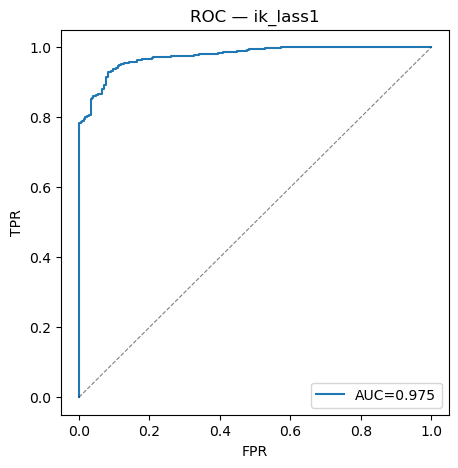

In [6]:
z = np.load(RESULTS/'roc_curves'/f'{cfg}.npz', allow_pickle=True)
fig, ax = plt.subplots(figsize=(5,5))
ax.plot(z['fpr'], z['tpr'], lw=1.5, label=f'AUC={float(z["auc"]):.3f}')
ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title(f'ROC — {cfg}'); ax.legend()
plt.show()

## Solve times (small problems only)
AC-OPF has no `solve_times.json` — its data predates that record.

In [7]:
p = RESULTS/cfg/'solve_times.json'
print(json.loads(p.read_text()) if p.exists() else 'no solve_times.json for this config')

{'key': 'ik_lass1', 'n_relax_solves': 25000, 'mean_relax_solve_s': 0.16006984067351557, 'n_local_solves': 5000, 'mean_local_solve_s': 0.14758276200131512}


## Knapsack + branch-and-bound
Certification AUC (settled) and the B&B arms (under analysis — see team notes).

In [8]:
display(pd.read_csv(RESULTS/'roc_auc_knapsack.csv'))
bnb = RESULTS/'robust_knapsack'/'bnb_summary.csv'
display(pd.read_csv(bnb) if bnb.exists() else 'no bnb_summary.csv')

,config,n_train,n_test,mean_cost,mae,mean_greedy_gap,auc,n_pos,n_neg,delta0
0,knapsack_n20000,20000,5000,28.783643,0.190504,0.206922,0.785092,4544,15456,0.028784
1,knapsack_n80000,80000,20000,28.760523,0.142319,0.209855,0.838828,17888,62112,0.028761


,config,n_instances,nodes_mean,nodes_ci_lo,nodes_ci_hi,time_mean,time_ci_lo,time_ci_hi,node_speedup,time_speedup,unsafe_rate,mean_gap_when_unsafe,max_gap_when_unsafe
0,baseline,200,570.560,504.301265,636.818735,0.450412,0.397190,0.503633,1.000000,1.000000,0.000,0.000000,0.000000
1,oracle,200,403.650,358.029619,449.270381,0.315271,0.279276,0.351265,1.413502,1.428650,0.000,0.000000,0.000000
2,nn,200,352.275,315.761930,388.788070,0.278008,0.248694,0.307322,1.619644,1.620141,0.235,0.026986,0.423803
